PINN for the prediction of the critical temperature in common superconductors

Starting Training...
Epoch  500 | Total Loss: 1.6110e+00 (Data: 1.3280e+00, Physics: 1.4151e-01)
Epoch 1000 | Total Loss: 1.1551e+00 (Data: 9.1630e-01, Physics: 1.1940e-01)
Epoch 1500 | Total Loss: 8.8839e-02 (Data: 1.9846e-03, Physics: 4.3427e-02)
Epoch 2000 | Total Loss: 3.0752e-02 (Data: 5.6408e-04, Physics: 1.5094e-02)
Epoch 2500 | Total Loss: 1.6262e-02 (Data: 8.1874e-04, Physics: 7.7215e-03)
Epoch 3000 | Total Loss: 1.3118e-02 (Data: 6.3492e-04, Physics: 6.2416e-03)
Epoch 3500 | Total Loss: 6.0649e-03 (Data: 5.3252e-05, Physics: 3.0058e-03)
Epoch 4000 | Total Loss: 9.8323e-03 (Data: 4.9571e-06, Physics: 4.9137e-03)
Epoch 4500 | Total Loss: 5.4119e-03 (Data: 3.1643e-05, Physics: 2.6901e-03)
Epoch 5000 | Total Loss: 6.2624e-03 (Data: 6.5337e-04, Physics: 2.8045e-03)


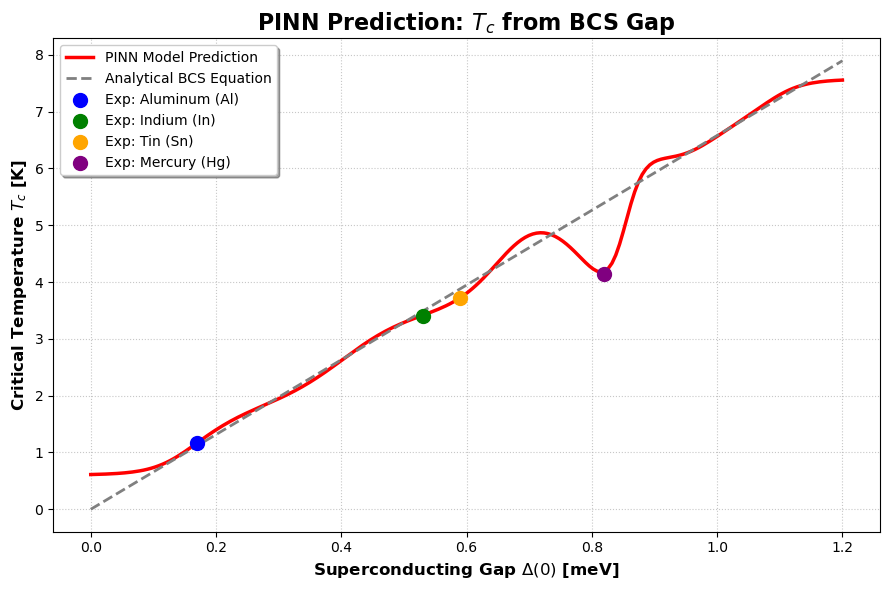

In [3]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

###########
## MODEL ##
###########
class BCS_PINN(nn.Module):
    def __init__(self):
        super(BCS_PINN, self).__init__()
        # Using the exact architecture requested
        self.hidden_layer1 = nn.Linear(1, 40)
        self.hidden_layer2 = nn.Linear(40, 20)
        self.hidden_layer3 = nn.Linear(20, 10)
        self.hidden_layer4 = nn.Linear(10, 5)
        self.output_layer = nn.Linear(5, 1)

        # Physics Constant: Boltzmann constant in meV/K
        self.k_B_meV = 0.08617  

        params = list(self.parameters())

        # Optimizer and Loss
        self.optimizer = torch.optim.Adam(params, lr=0.005)
        self.criterion = torch.nn.MSELoss()

    def forward(self, x):
        # x is the Superconducting Gap (Delta) in meV
        inputs = torch.cat([x], axis=1)
        layer1_out = torch.sigmoid(self.hidden_layer1(inputs))
        layer2_out = torch.sigmoid(self.hidden_layer2(layer1_out))
        layer3_out = torch.sigmoid(self.hidden_layer3(layer2_out))
        layer4_out = torch.sigmoid(self.hidden_layer4(layer3_out))
        
        # For regression, no activation is used in output layer
        # Output is the Critical Temperature (Tc) in Kelvin
        output = self.output_layer(layer4_out)
        return output

    def diff_eq(self, gap_val):
        """
        This method returns the physics constraint function.
        Instead of a PDE, we use the BCS algebraic relation: Delta = 1.764 * k_B * Tc
        :param gap_val: the energy gap values (Delta) sampled from the domain
        :return: the residual of the BCS equation
        """
        Tc_pred = self.forward(gap_val)
        
        # Calculate theoretical Gap based on the predicted Tc
        # f(x) = Delta - 1.764 * k_B * Tc = 0
        bcs_residual = gap_val - (1.764 * self.k_B_meV * Tc_pred)
        
        return bcs_residual 

    def train_step(self, diff_eq_x, dataset_x, amplitudes):
        """
        Trains the NN model using the data loss and the physics equation loss.
        :param diff_eq_x: random gap values to enforce the BCS physics constraint
        :param dataset_x: gap values from our known dataset
        :param amplitudes: true Tc "labels" from the dataset
        :return: total loss
        """
        self.optimizer.zero_grad()

        # 1. Data Loss
        prediction = self.forward(dataset_x)
        loss_data = self.criterion(prediction, amplitudes)
        
        # 2. Physics Loss (BCS Equation)
        f_out = self.diff_eq(diff_eq_x)
        zeros_diff_eq = torch.zeros_like(f_out, requires_grad=False)
        loss_diff_eq = self.criterion(f_out, zeros_diff_eq)

        # 3. Total Loss and Backpropagation
        # Applying a weight (lambda) to the physics loss can help convergence
        loss_total = loss_data + 2.0 * loss_diff_eq 
        loss_total.backward()
        self.optimizer.step()

        return loss_total.item(), loss_data.item(), loss_diff_eq.item()


##############
## TRAINING ##
############## 
def main():
    # Experimental Data for simple elemental superconductors
    # Values: Gap Delta(0) in meV, Critical Temperature Tc in Kelvin
    elements = ['Aluminum (Al)', 'Indium (In)', 'Tin (Sn)', 'Mercury (Hg)']
    delta_data_np = np.array([0.17, 0.53, 0.59, 0.82], dtype=np.float32).reshape(-1, 1)
    tc_data_np    = np.array([1.17, 3.41, 3.72, 4.15], dtype=np.float32).reshape(-1, 1)

    # Convert to Torch Tensors
    delta_dataset = torch.tensor(delta_data_np, requires_grad=True)
    tc_dataset    = torch.tensor(tc_data_np, requires_grad=True)

    # Instantiate the model
    net = BCS_PINN()

    n_epochs = 5000
    batch_size = 100
    gap_min, gap_max = 0.0, 1.2 # Domain of the gap in meV

    print("Starting Training...")
    for epoch in range(n_epochs):
        # Collocation points to enforce physics (random gaps in domain)
        gap_eq = (gap_max - gap_min) * torch.rand(size=(batch_size, 1), requires_grad=True, dtype=torch.float32) + gap_min

        loss_tot, loss_dat, loss_phys = net.train_step(diff_eq_x=gap_eq, dataset_x=delta_dataset, amplitudes=tc_dataset)

        if (epoch + 1) % 500 == 0:
            print(f"Epoch {epoch+1:4d} | Total Loss: {loss_tot:.4e} (Data: {loss_dat:.4e}, Physics: {loss_phys:.4e})")

    ############## TEST ##############
    with torch.no_grad():
        # Generate a sequence of gap values for the continuous prediction curve
        delta_test = np.linspace(gap_min, gap_max, 200).reshape(-1, 1)
        delta_test_tensor = torch.tensor(delta_test, dtype=torch.float32)
        
        # Model predictions
        tc_pred = net(delta_test_tensor).numpy()
        
        # Ground truth analytical BCS relation (Tc = Delta / (1.764 * k_B))
        tc_true = delta_test / (1.764 * net.k_B_meV)

    ## Plotting ##
    fig, ax = plt.subplots(figsize=(9, 6))
    
    # Plot Continuous Lines
    ax.plot(delta_test, tc_pred, color='red', linewidth=2.5, label="PINN Model Prediction")
    ax.plot(delta_test, tc_true, '--', color='grey', linewidth=2, label="Analytical BCS Equation")
    
    # Plot Experimental Dataset Points
    colors = ['blue', 'green', 'orange', 'purple']
    for i, txt in enumerate(elements):
        ax.scatter(delta_data_np[i], tc_data_np[i], color=colors[i], s=100, zorder=5, label=f"Exp: {txt}")

    # Formatting
    ax.legend(loc='upper left', shadow=True, fontsize=10)
    ax.set_xlabel('Superconducting Gap $\Delta(0)$ [meV]', fontsize=12, weight='bold')
    ax.set_ylabel('Critical Temperature $T_c$ [K]', fontsize=12, weight='bold')
    ax.set_title('PINN Prediction: $T_c$ from BCS Gap', fontsize=16, weight='bold')
    ax.grid(True, linestyle=':', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

if __name__=="__main__":
    main()